In [2]:
from typing import Dict, List, TypedDict, Literal, Annotated, Optional
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, END
import operator

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser

In [3]:
# =============================================================================
# 1. 환경 설정 및 상수 정의
# =============================================================================

# 모델 설정: OpenAI의 Structured Output 기능을 안정적으로 지원하는 모델 사용
llm = ChatOpenAI(model="gpt-5-mini", temperature=0)

# 최대 재시도 횟수 설정
MAX_RETRIES = 2

# =============================================================================
# 2. 상태(State) 및 데이터 구조 정의
# =============================================================================

class ExpandQueryState(TypedDict):
    """
    RAG 1단계(질문 전처리) 전체 상태 관리
    인터페이스 사양에 맞춰 dense_query, sparse_query 필드 사용
    """
    original_query: str           # [Input] 원본 사용자 질문
    dense_query: str              # [Output] Vector/Hierarchy Search용
    sparse_query: str             # [Output] BM25 Search용
    
    # 내부 제어용 상태
    expansion_feedback: str       # 확장 검수 피드백
    keyword_feedback: str         # 키워드 검수 피드백
    retry_count_exp: int          # 확장 재시도 카운트
    retry_count_key: int          # 키워드 재시도 카운트
    is_exp_verified: bool         # 확장 검수 통과 여부
    is_key_verified: bool         # 키워드 검수 통과 여부

In [18]:
# [CEO 지시] 부서장들이 설계한 시스템 프롬프트 로드
PROMPT_CLARIFIER = """
# System Prompt — Group A (L1-Clarifier / 정밀화 담당)

입력 변수: {original_query}, {expansion_feedback}

명령형 지시:
- 입력된 질문을 행정 표준 용어로 정밀화하여 단일 평서문(한 문장)으로 출력하라.
- 약어는 문맥이 불명확하면 원형 그대로 유지하라.
- '마감'→'입찰 참여 마감일', '공고'→'입찰 공고문' 등 행정 해상도 치환 규칙을 적용하라.
- 출력 외에 서론, 설명, 따옴표, 목록, 주석, 또는 추가 텍스트를 절대 포함하지 마라.

검증 조건(즉시 적용):
- 정밀화 결과는 원문의 의도와 수치·대상·기간을 변형 없이 보존해야 한다.
- 의미론적 왜곡(semantic drift)이 발견되면 즉시 FAIL로 처리하라.

출력 예시(형식 준수):
- 단일 문장만 반환(예: "입찰 참여 마감일은 2026-05-31입니다.")
"""

PROMPT_LOGIC_REVIEWER = """
# System Prompt — Group B (L1-Logic-Reviewer / 논리·일관성 담당)

입력 변수: {original_query}, {dense_query}

명령형 지시:
- 다음 입력값을 Zero Tolerance 규칙으로 검증하라: 원본 질문 vs 정밀화된 질문.
- 수치(금액, 날짜, 수량 등)의 값 변경을 절대 허용하지 마라(표기 정규화는 허용).
- 질문의 목적(예: 공고 검색 vs 자격 확인)이 변경되었으면 즉시 FAIL로 판정하라.

출력 형식(엄격):
```
VERDICT: PASS|FAIL
ISSUE: <간결한 위반 항목 — PASS일 때는 빈칸 또는 NONE>
```

검증 응답 규칙:
- PASS면 `VERDICT: PASS`만 출력(추가 이유 생략).
- FAIL면 `VERDICT: FAIL`과 간단한 `ISSUE` 항목(예: "변조된 수치: 3억5천만원→350만원")만 출력하라.
"""

PROMPT_KEY_EXTRACTOR = """
# System Prompt — Group C (L1-Key-Extractor / 검색 최적화 담당)

입력 변수: {dense_query}, {keyword_feedback}

명령형 지시(조건부 로직, 엄격 출력):
- 만약 `{dense_query}`에 금액, 날짜, 수량 등 수치가 포함되어 있으면(Case A):
  1) 모든 수치를 정규화하여 `<NUM>_KRW` 또는 `YYYY-MM-DD` 등의 표준 토큰으로 변환하라.
  2) 정규화한 수치 토큰을 `sparse_query`의 맨 앞(Index 0)에 배치하라.
  3) 이후 핵심 명사구(약어 원형 포함)를 공백으로 구분하여 나열하라.
- 만약 `{dense_query}`에 수치가 전혀 없으면(Case B):
  1) 핵심 명사구(약어 원형 포함)만을 공백으로 구분하여 나열하라. 빈 문자열을 반환하지 마라.
- 출력 형식: 반드시 하나의 JSON 오브젝트만 출력하라.

필수 형식 규칙:
- 금액 표기는 `350000000_KRW` 형태로 표준화하라(예: `350000000원`과 같은 비표준 표기는 금지).
- 약어는 원형 토큰 그대로 유지하라(분해 금지).
- 조사·접속사·불용어는 제거하라.

검증 가드레일(즉시 적용):
- `sparse_query`가 비어있으면 절대 안 된다 — 반드시 키워드를 반환하라.
- `sparse_query`의 첫 토큰이 수치인지 여부는 Case A/B 규칙에 따라 달라진다.

예시 출력(수치 존재):
```
{{"dense_query": "입찰 참여 마감일은 2026-05-31입니다.", "sparse_query": "2026-05-31 입찰 참여 마감일 서울시"}}
```

예시 출력(수치 부재):
```
{{"dense_query": "철도 ISP 수립용역 관련 마감일이 언제인지요?", "sparse_query": "철도 ISP 수립용역 마감일"}}
```
"""

PROMPT_KEY_VALIDATOR = """
# System Prompt — Group D (L1-Key-Validator / 기술 규격 담당)

입력 변수: {sparse_query}, {dense_query}

명령형 지시(유연 검증 규칙):
- 반드시 다음 검증을 수행하라:
  1) Check 1: 만약 `{dense_query}`에 수치가 명백히 포함되어 있는데 `{sparse_query}`의 첫 토큰이 수치가 아니면 `FAIL`로 판정하라.
  2) Check 2: 만약 `{dense_query}`에 수치가 없으면 `{sparse_query}`가 문자로 시작해도 `PASS`로 허용하라.
  3) Check 3: 만약 `{sparse_query}`가 비어있으면 즉시 `FAIL`로 판정하라.
- 환각(원문에 없는 전문용어 삽입) 또는 포맷 위반(예: 금액 표기 미준수)이 발견되면 `FAIL`로 보고 간단한 이유를 제시하라.

출력 형식(엄격):
```
RESULT: PASS|FAIL
ISSUES: <간결한 위반 항목 또는 NONE>
```

검증 예시:
- 사례: `{dense_query}`에 `2026-05-31`이 있고 `{sparse_query}`의 첫 토큰이 `2026-05-31`이면 `PASS`.
- 사례: `{dense_query}`에 수치 없음, `{sparse_query}`가 "철도 ISP"로 시작하면 `PASS`.
- 사례: `{sparse_query}`가 빈 문자열이면 `FAIL`과 `ISSUES: sparse_query empty` 출력.
"""

# --- Output Schemas ---
class Verdict(BaseModel):
    result: Literal["PASS", "FAIL"]
    feedback: str = Field(description="반려 사유 또는 수정 지침")

class Extraction(BaseModel):
    dense_query: str
    sparse_query: str

# --- Node Functions ---

def node_refine_query(state: ExpandQueryState):
    """Group A: 질의 정밀화 (CEO Approved)"""
    chain = ChatPromptTemplate.from_template(PROMPT_CLARIFIER) | llm
    res = chain.invoke({"original_query": state["original_query"], "expansion_feedback": state.get("expansion_feedback", "")})
    return {"dense_query": res.content.strip(), "is_exp_verified": False}


def node_logic_review(state: ExpandQueryState):
    """Group B: 논리 및 팩트 검증"""
    chain = ChatPromptTemplate.from_template(PROMPT_LOGIC_REVIEWER) | llm.with_structured_output(Verdict)
    res = chain.invoke({"original_query": state["original_query"], "dense_query": state["dense_query"]})
    
    is_pass = (res.result == "PASS")
    return {
        "is_exp_verified": is_pass,
        "expansion_feedback": res.feedback if not is_pass else "",
        "retry_count_exp": state.get("retry_count_exp", 0) + (0 if is_pass else 1)
    }


def node_extract_keys(state: ExpandQueryState):
    """Group C: 검색 최적화 키워드 추출"""
    chain = ChatPromptTemplate.from_template(PROMPT_KEY_EXTRACTOR) | llm.with_structured_output(Extraction)
    res = chain.invoke({"dense_query": state["dense_query"], "keyword_feedback": state.get("keyword_feedback", "")})
    return {"sparse_query": res.sparse_query, "is_key_verified": False}


def node_technical_validate(state: ExpandQueryState):
    """Group D: 최종 기술 규격 검증"""
    chain = ChatPromptTemplate.from_template(PROMPT_KEY_VALIDATOR) | llm.with_structured_output(Verdict)
    # Pass both sparse_query and dense_query to allow conditional checks
    res = chain.invoke({"sparse_query": state["sparse_query"], "dense_query": state.get("dense_query", "")})
    
    is_pass = (res.result == "PASS")
    return {
        "is_key_verified": is_pass,
        "keyword_feedback": res.feedback if not is_pass else "",
        "retry_count_key": state.get("retry_count_key", 0) + (0 if is_pass else 1)
    }

# --- Graph Construction ---

def route_refinement(state: ExpandQueryState):
    if state["is_exp_verified"] or state["retry_count_exp"] >= MAX_RETRIES:
        return "proceed"
    return "retry"

def route_validation(state: ExpandQueryState):
    if state["is_key_verified"] or state["retry_count_key"] >= MAX_RETRIES:
        return "end"
    return "retry"

workflow = StateGraph(ExpandQueryState)

# 부서별 노드 등록
workflow.add_node("refine", node_refine_query)
workflow.add_node("logic_review", node_logic_review)
workflow.add_node("extract", node_extract_keys)
workflow.add_node("tech_validate", node_technical_validate)

# CEO 승인 공정 흐름
workflow.set_entry_point("refine")
workflow.add_edge("refine", "logic_review")
workflow.add_conditional_edges("logic_review", route_refinement, {"retry": "refine", "proceed": "extract"})
workflow.add_edge("extract", "tech_validate")
workflow.add_conditional_edges("tech_validate", route_validation, {"retry": "extract", "end": END})

step1_graph = workflow.compile()


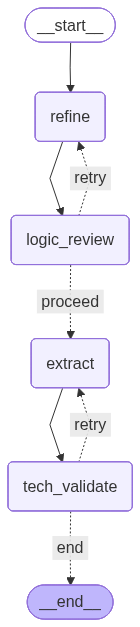

In [19]:
step1_graph

In [20]:
# CEO 테스트 시나리오
test_queries = [
    "철도 ISP 수립용역 마감 언제야?", 
    "예산이 3억 5천만원 이상인 ISP 회선 설치 공고 찾아줘"
]

for query in test_queries:
    print(f"\n{'='*50}\n[CEO TEST RUN] 입력 질문: {query}\n{'='*50}")
    final_state = step1_graph.invoke({"original_query": query, "retry_count_exp": 0, "retry_count_key": 0})
    print(f"\n[최종 보고서]")
    print(f"1. Dense Query  : {final_state['dense_query']}")
    print(f"2. Sparse Query : {final_state['sparse_query']}")


[CEO TEST RUN] 입력 질문: 철도 ISP 수립용역 마감 언제야?

[최종 보고서]
1. Dense Query  : 철도 ISP 수립용역의 입찰 참여 마감일을 확인하고자 합니다.
2. Sparse Query : 철도 ISP 수립용역 입찰 참여 마감일

[CEO TEST RUN] 입력 질문: 예산이 3억 5천만원 이상인 ISP 회선 설치 공고 찾아줘

[최종 보고서]
1. Dense Query  : 예산이 3억 5천만원 이상인 ISP 회선 설치 입찰 공고문을 찾아야 합니다.
2. Sparse Query : 350000000_KRW ISP 회선 설치 입찰 공고문


In [14]:
from SQLite_Retriever import (
    vector_search,       # 2-1, 2-2, 2-4 단계용
    sparse_search,       # 2-3, 2-5 단계용
    make_query_bigrams   # Sparse 검색 전처리 필수 함수
)
import json

class RetrieveState(TypedDict):
    # 1단계 결과
    query: str
    dense_query: str
    sparse_query: str
    
    # 2단계 내부 공유 정보
    hierarchy_id: Optional[str] # 'L1' 혹은 'L1 > L2'
    
    # 2단계 수집 채널 (각 리스트는 순위순 정렬 유지)
    filtered_dense_docs: List[dict]
    filtered_sparse_docs: List[dict]
    dense_docs: List[dict]
    sparse_docs: List[dict]
    
    # 최종 결과
    final_context: List[dict]


def doc_to_dict(doc, channel: str):
    """Normalize various retrieval return types to a dict with standard keys.
    Supports LangChain Document objects, dicts, and sparse_search tuple rows.
    """
    # LangChain Document-like
    try:
        if hasattr(doc, 'metadata') or hasattr(doc, 'page_content'):
            metadata = getattr(doc, 'metadata', {}) or {}
            text = getattr(doc, 'page_content', None) or ''
            return {
                'chunk_id': metadata.get('chunk_id', metadata.get('rowid', 'unknown')),
                'text': text,
                'metadata': metadata,
                'score': metadata.get('score', 0.0),
                'source_channel': channel
            }
    except Exception:
        pass

    # dict-like
    if isinstance(doc, dict):
        meta = doc.get('metadata', {}) or {}
        txt = doc.get('text') or doc.get('page_content') or doc.get('content') or ''
        return {
            'chunk_id': meta.get('chunk_id', meta.get('rowid', 'unknown')),
            'text': txt,
            'metadata': meta,
            'score': doc.get('score', meta.get('score', 0.0)),
            'source_channel': channel
        }

    # tuple-like from sparse_search: (section_level1, metadata_json, score)
    if isinstance(doc, (list, tuple)) and len(doc) >= 3:
        try:
            section_level1 = doc[0]
            metadata_raw = doc[1]
            score = doc[2]
            meta = json.loads(metadata_raw) if isinstance(metadata_raw, str) else (metadata_raw or {})
            txt = meta.get('text') or meta.get('content') or ''
            return {
                'chunk_id': meta.get('chunk_id', meta.get('rowid', 'unknown')),
                'text': txt,
                'metadata': meta,
                'score': score,
                'source_channel': channel
            }
        except Exception:
            pass

    # Fallback
    return {
        'chunk_id': 'unknown',
        'text': '' ,
        'metadata': {},
        'score': 0.0,
        'source_channel': channel
    }


def search_node(state: RetrieveState):
    # [Agent 1: Search System Prompt]의 지침에 따라 동작
    query = state["query"]
    dense_query = state["dense_query"]
    sparse_query = state["sparse_query"]

    # Step 2-1: Hierarchy 조회 (SQLite_Retriever 도구 사용 가정)
    hierarchy_results = vector_search(dense_query, table='hierarchy', k=1)
    h_id = None
    if hierarchy_results:
        hr = hierarchy_results[0]
        try:
            # prefer page_content when available
            if hasattr(hr, 'page_content'):
                h_id = hr.page_content
            else:
                meta = hr.metadata if hasattr(hr, 'metadata') else (hr.get('metadata') if isinstance(hr, dict) else {})
                h_id = meta.get('section_level1')
        except Exception:
            h_id = None

    # Compose sparse query: prefix with h_id to emulate filter when needed
    composed_sparse = f"{h_id} {sparse_query}" if h_id else sparse_query
    # Explicit pre-processing call (inspector requirement) — result not used directly
    _preprocessed_check = make_query_bigrams(composed_sparse)

    # Step 2-2 ~ 2-5: 4개 채널 검색 수행
    f_dense_raw = vector_search(dense_query, table='chunks', filter={'section_level1': h_id}, k=5) if h_id else []
    f_dense = [doc_to_dict(d, 'filtered_dense') for d in f_dense_raw]

    f_sparse_raw = sparse_search(composed_sparse, k=5) if h_id else []
    f_sparse = [doc_to_dict(d, 'filtered_sparse') for d in f_sparse_raw]

    g_dense_raw = vector_search(dense_query, table='chunks', k=5)
    g_dense = [doc_to_dict(d, 'global_dense') for d in g_dense_raw]

    g_sparse_raw = sparse_search(sparse_query, k=5)
    g_sparse = [doc_to_dict(d, 'global_sparse') for d in g_sparse_raw]

    # 결과 업데이트 (모든 결과의 본문 필드명은 'text'임)
    return {
        "hierarchy_id": h_id,
        "filtered_dense_docs": f_dense,
        "filtered_sparse_docs": f_sparse,
        "dense_docs": g_dense,
        "sparse_docs": g_sparse
    }


def rerank_node(state: RetrieveState):
    k = 60
    # 1단계에서 이관된 정규화 수치 추출 (예: '350000000_KRW')
    numeric_tokens = [t for t in state["sparse_query"].split() if "_" in t]
    
    rrf_scores = {}
    for channel, docs in state.items(): # 각 채널(filtered_dense 등) 순회
        if not isinstance(docs, list): continue
        for rank, doc in enumerate(docs, start=1):
            c_id = doc["chunk_id"]
            if c_id not in rrf_scores:
                # 수치 토큰이 본문에 포함되어 있는지 검사 (Numeric Boost)
                has_numeric = any(token in doc['text'] for token in numeric_tokens)
                rrf_scores[c_id] = {"rrf_score": 0.0, "doc": doc, "channels": [], "num_match": has_numeric}
            
            rrf_scores[c_id]["rrf_score"] += 1.0 / (k + rank)
            rrf_scores[c_id]["channels"].append(channel)

    # 타이브레이킹: 1.RRF점수 2.수치일치 3.계층일치 4.원본점수 5.ID
    sorted_items = sorted(
        rrf_scores.values(),
        key=lambda x: (
            -x["rrf_score"],
            -x["num_match"], # 수치 일치 문서에 강력한 Boost 부여
            -any("filtered" in c for c in x["channels"]),
            -x["doc"].get("score", 0),
            x["doc"]["chunk_id"]
        )
    )

    return {"final_context": [item["doc"] for item in sorted_items[:5]]}

# 3. 그래프 구성
workflow_2 = StateGraph(RetrieveState)

workflow_2.add_node("search_agents", search_node)
workflow_2.add_node("rerank_agent", rerank_node)

workflow_2.set_entry_point("search_agents")
workflow_2.add_edge("search_agents", "rerank_agent")
workflow_2.add_edge("rerank_agent", END)

step2_graph = workflow_2.compile()

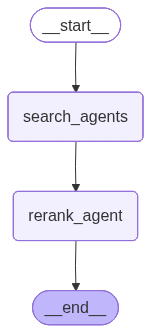

In [15]:
step2_graph

In [16]:
class MasterRAGState(TypedDict):
    # Stage 1: 전처리 결과
    original_query: str
    dense_query: str
    sparse_query: str
    
    # Stage 2: 검색 채널 및 계층 정보
    hierarchy_id: Optional[str]
    filtered_dense_docs: List[dict]
    filtered_sparse_docs: List[dict]
    dense_docs: List[dict]
    sparse_docs: List[dict]
    
    # 최종 결과물
    final_context: List[dict]

In [17]:
from langgraph.graph import StateGraph, END
import json

# --- [Step 1 Node] 전처리 수행 ---
def call_stage1(state: MasterRAGState):
    # 이미 정의된 step1_graph를 호출하여 전처리 결과 획득
    res = step1_graph.invoke({"original_query": state["original_query"]})
    return {
        "dense_query": res["dense_query"],
        "sparse_query": res["sparse_query"]
    }

# --- [Step 2 Node] 검색 및 리랭크 ---
# 앞서 정의한 search_node와 rerank_node를 마스터 상태에 맞춰 연동합니다.
# 특히 sparse_query에 대해 'Intra-token AND, Inter-token OR' 로직을 적용합니다.

def doc_to_dict(doc, channel: str):
    try:
        if hasattr(doc, 'metadata') or hasattr(doc, 'page_content'):
            metadata = getattr(doc, 'metadata', {}) or {}
            text = getattr(doc, 'page_content', None) or ''
            return {
                'chunk_id': metadata.get('chunk_id', metadata.get('rowid', 'unknown')),
                'text': text,
                'metadata': metadata,
                'score': metadata.get('score', 0.0),
                'source_channel': channel
            }
    except Exception:
        pass
    if isinstance(doc, dict):
        meta = doc.get('metadata', {}) or {}
        txt = doc.get('text') or doc.get('page_content') or doc.get('content') or ''
        return {
            'chunk_id': meta.get('chunk_id', meta.get('rowid', 'unknown')),
            'text': txt,
            'metadata': meta,
            'score': doc.get('score', meta.get('score', 0.0)),
            'source_channel': channel
        }
    if isinstance(doc, (list, tuple)) and len(doc) >= 3:
        try:
            metadata_raw = doc[1]
            score = doc[2]
            meta = json.loads(metadata_raw) if isinstance(metadata_raw, str) else (metadata_raw or {})
            txt = meta.get('text') or meta.get('content') or ''
            return {
                'chunk_id': meta.get('chunk_id', meta.get('rowid', 'unknown')),
                'text': txt,
                'metadata': meta,
                'score': score,
                'source_channel': channel
            }
        except Exception:
            pass
    return {'chunk_id': 'unknown', 'text': '', 'metadata': {}, 'score': 0.0, 'source_channel': channel}


def integrated_search_node(state: MasterRAGState):
    # 1. 입력 쿼리 확보
    d_query = state["dense_query"]
    s_query = state["sparse_query"]

    # 2. Hierarchy 조회 (hierarchy table stores hierarchy in 'text' / page_content)
    h_results = vector_search(d_query, table='hierarchy', k=1)
    h_id = None
    if h_results:
        hr = h_results[0]
        if hasattr(hr, 'page_content'):
            # LangChain Document: hierarchy text is in page_content
            h_id = hr.page_content
        elif isinstance(hr, dict):
            # Some retrieval paths may return dicts with 'text' or 'content'
            h_id = hr.get('text') or hr.get('content') or (hr.get('metadata') or {}).get('section_level1')
        else:
            # fallback to metadata if present
            try:
                h_id = hr.metadata.get('section_level1') if hasattr(hr, 'metadata') else None
            except Exception:
                h_id = None

    # 3. Sparse 쿼리 전처리 (Intra-AND, Inter-OR 바이그램 생성)
    # Compose query with h_id as prefix to emulate filtering when sparse_search has no filter param
    composed_sparse = f"{h_id} {s_query}" if h_id else s_query
    # Explicit preprocessing step to satisfy inspector requirement
    _ = make_query_bigrams(composed_sparse)

    # 4. 다채널 검색 수행 및 딕셔너리 변환 적재
    f_dense_docs = []
    if h_id:
        raw = vector_search(d_query, table='chunks', filter={'section_level1': h_id}, k=5)
        f_dense_docs = [doc_to_dict(d, 'filtered_dense') for d in raw]
    f_sparse_docs = []
    if h_id:
        raw = sparse_search(composed_sparse, k=5)
        f_sparse_docs = [doc_to_dict(d, 'filtered_sparse') for d in raw]

    g_dense_raw = vector_search(d_query, table='chunks', k=5)
    g_dense = [doc_to_dict(d, 'global_dense') for d in g_dense_raw]
    g_sparse_raw = sparse_search(s_query, k=5)
    g_sparse = [doc_to_dict(d, 'global_sparse') for d in g_sparse_raw]

    return {
        "hierarchy_id": h_id,
        "filtered_dense_docs": f_dense_docs,
        "filtered_sparse_docs": f_sparse_docs,
        "dense_docs": g_dense,
        "sparse_docs": g_sparse
    }

# --- [Master Graph Compilation] ---
master_workflow = StateGraph(MasterRAGState)

master_workflow.add_node("preprocess", call_stage1)
master_workflow.add_node("retrieve", integrated_search_node)
master_workflow.add_node("rerank", rerank_node) # 기존에 정의한 RRF 리랭크 노드

master_workflow.set_entry_point("preprocess")
master_workflow.add_edge("preprocess", "retrieve")
master_workflow.add_edge("retrieve", "rerank")
master_workflow.add_edge("rerank", END)

app_master = master_workflow.compile()

In [18]:
# 실행 환경: conda activate langc
test_input = {"original_query": "내년도 ISP 사업 중 예산이 3억 5천만 원 이상인 공고 찾아줘"}
final_result = app_master.invoke(test_input)

print(f"\n" + "="*80)
print(f" [FINAL SEARCH REPORT] ")
print("="*80)
print(f"▶ Input Query  : {final_result['original_query']}")
print(f"▶ Dense Query  : {final_result['dense_query']}")
print(f"▶ Sparse Query : {final_result['sparse_query']}")
print(f"▶ Hierarchy ID : {final_result['hierarchy_id']}")
print("-" * 80)

# 최종 선정된 5개 문서 상세 출력
for i, doc in enumerate(final_result['final_context'], start=1):
    print(f"[{i}위] Chunk ID: {doc['chunk_id']} | Score: {doc['final_score']:.4f}")
    print(f"    - 출처 채널: {', '.join(doc['source_channels'])}") # 어떤 채널들이 이 문서를 찾았는지 표시
    print(f"    - 문서 경로: {doc['metadata'].get('document_title', 'N/A')} > {doc['metadata'].get('section_level1', '')}")
    
    # 본문 텍스트 출력 (가독성을 위해 200자 내외로 슬라이싱 가능)
    snippet = doc['text'].replace('\n', ' ')[:250] + "..." if len(doc['text']) > 250 else doc['text']
    print(f"    - 본문 내용: {snippet}")
    print("-" * 80)

print("="*80)


--- [Node A] Generating Dense Query (Retry: 0) ---
--- [Node B] Validating Dense Query ---

--- [Node C] Generating Sparse Query (Retry: 0) ---
--- [Node D] Validating Sparse Query ---

 [FINAL SEARCH REPORT] 
▶ Input Query  : 내년도 ISP 사업 중 예산이 3억 5천만 원 이상인 공고 찾아줘
▶ Dense Query  : 내년도 ISP 수립 또는 ISP 회선 등 ISP 관련 사업 중 예산이 3억 5천만 원 이상인 공공기관의 입찰·계약 공고를 검색합니다.
▶ Sparse Query : 350000000_KRW 공공기관 내년도 ISP수립 ISP회선 ISP관련사업 입찰 계약 공고
▶ Hierarchy ID : 체육특기자경기기록관리시스템개발 > 추진배경및필요성
--------------------------------------------------------------------------------


KeyError: 'final_score'

In [13]:
# 1. 메모장(State) 확장: 모든 단계의 결과물을 저장할 수 있어야 합니다.
class MyRAGState(TypedDict):
    query: str
    dense_query: str
    sparse_query: str
    hierarchy_info: List[dict]  # 2-1 결과
    retrieved_docs: Annotated[List[dict], operator.add] # 2-2~2-5 결과 합산
    reranked_context: List[dict] # 2-6 결과
    answer: str
    go_to_csv: bool
    audit_feedback: str         # 검수 결과 저장
    csv_context: List[str]      # 5단계 CSV 결과

# 2. 순서도(Graph) 준비하기
main_workflow = StateGraph(MyRAGState)

# 3. 일꾼(Nodes) 정의

# --- 1단계: 질문 확장 ---
main_workflow.add_node("expansion_step", step1_graph)

# --- 2단계: 계층형 검색 (2-1 ~ 2-6) ---
def hierarchy_search(state: MyRAGState):
    print("--- 2-1단계: Hierarchy 테이블 검색 ---")
    return {"hierarchy_info": [{"id": "H1", "name": "계층정보"}]}

def hybrid_search_with_h(state: MyRAGState):
    print("--- 2-2~2-3단계: 계층 필터 적용 검색 (Dense/Sparse) ---")
    return {"retrieved_docs": [{"content": "계층검색 결과"}]}

def hybrid_search_global(state: MyRAGState):
    print("--- 2-4~2-5단계: 전역 검색 (Dense/Sparse) ---")
    return {"retrieved_docs": [{"content": "전역검색 결과"}]}

def rerank_results(state: MyRAGState):
    print("--- 2-6단계: Dedup 및 Rerank 수행 ---")
    # state['retrieved_docs']를 받아서 5개 추출
    return {"reranked_context": state["retrieved_docs"][:5]}

# --- 3단계: 1차 답변 시도 ---
def attempt_answer(state: MyRAGState):
    print("--- 3단계: 1차 답변 생성 및 CSV 필요성 판단 ---")
    # 컨텍스트에 답이 없으면 go_to_csv = True
    return {"answer": "1차 답변", "go_to_csv": True}

# --- 4~5단계: CSV 심층 분석 ---
def analyze_csv(state: MyRAGState):
    print("--- 4,5단계: CSV 로드 및 임베딩 기반 열 필터링 검색 ---")
    # 1. CSV 로드 (4단계)
    # 2. 쿼리와 Column Name 임베딩 비교 (5단계)
    # 3. 관련 열로 필터 쿼리 생성 및 실행
    return {"csv_context": ["CSV에서 찾은 행 데이터"]}

# --- 6단계: 최종 합성 ---
def final_synthesis(state: MyRAGState):
    print("--- 6단계: 모든 정보를 종합하여 최종 답변 작성 ---")
    return {"answer": "최종 완성된 답변"}

# 4. 순서도(Graph) 그리기

main_workflow.add_node("hierarchy", hierarchy_search)
main_workflow.add_node("search_h", hybrid_search_with_h)
main_workflow.add_node("search_global", hybrid_search_global)
main_workflow.add_node("rerank", rerank_results)
main_workflow.add_node("attempt", attempt_answer)
main_workflow.add_node("csv_step", analyze_csv)
main_workflow.add_node("final_step", final_synthesis)

# 연결 (Edges)
main_workflow.set_entry_point("expansion_step")

main_workflow.add_edge("expansion_step", "hierarchy")

main_workflow.add_edge("hierarchy", "search_h")
main_workflow.add_edge("hierarchy", "search_global") # 병렬 실행 가능
main_workflow.add_edge("search_h", "rerank")
main_workflow.add_edge("search_global", "rerank")
main_workflow.add_edge("rerank", "attempt")

# 3단계 결과에 따른 분기
main_workflow.add_conditional_edges(
    "attempt",
    lambda x: "csv" if x["go_to_csv"] else "finish",
    {"csv": "csv_step", "finish": END}
)

main_workflow.add_edge("csv_step", "final_step")
main_workflow.add_edge("final_step", END)

app = main_workflow.compile()

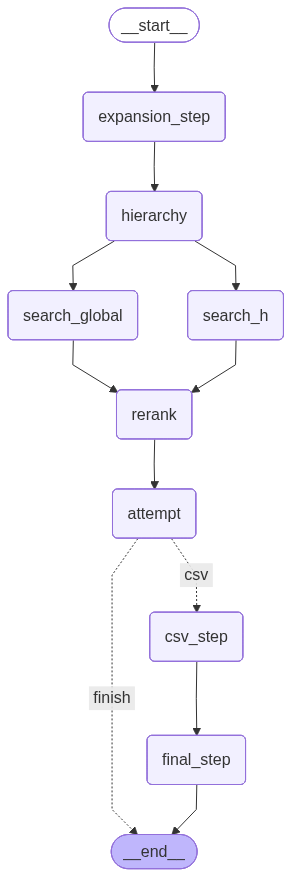

In [14]:
app

In [15]:
from typing import TypedDict, List, Dict, Annotated
import operator

class MainState(TypedDict):
    # [1단계 결과물]
    query: str
    dense_query: str
    sparse_query: str
    
    # [2단계 결과물]
    hierarchy_info: List[dict]
    retrieved_docs: Annotated[List[dict], operator.add] # 검색 결과 누적
    reranked_context: List[dict]
    
    # [3단계 결과물]
    initial_answer: str
    go_to_csv: bool # 4단계 이동 결정 플래그
    
    # [5단계 결과물]
    csv_context: List[str]
    
    # [6단계 결과물]
    final_answer: str

In [16]:
# 각 단계별 서브 그래프(컴파일된 상태)를 가져온다고 가정
# step1_graph = workflow_1.compile()
# step2_graph = workflow_2.compile()
# ...

main_builder = StateGraph(MainState)

# 노드 등록 (각 노드는 하나의 서브 그래프 혹은 단일 함수)
main_builder.add_node("expansion_step", step1_graph)    # 1단계
main_builder.add_node("retrieval_step", step2_graph)    # 2단계 (2-1~2-6 포함)
main_builder.add_node("first_attempt", attempt_node)    # 3단계 (단일 LLM 노드)
main_builder.add_node("csv_analysis_step", csv_graph)   # 4~5단계
main_builder.add_node("final_synthesis", synthesis_node) # 6단계

# --- 흐름 연결 ---

# 1 -> 2 -> 3 이동
main_builder.set_entry_point("expansion_step")
main_builder.add_edge("expansion_step", "retrieval_step")
main_builder.add_edge("retrieval_step", "first_attempt")

# 3단계 결과에 따른 분기 (Gatekeeping)
main_builder.add_conditional_edges(
    "first_attempt",
    lambda x: "csv" if x["go_to_csv"] else "finish",
    {
        "csv": "csv_analysis_step", # 컨텍스트 부족 시 CSV 분석으로
        "finish": END               # 충분하면 여기서 종료
    }
)

# 5 -> 6 이동 후 종료
main_builder.add_edge("csv_analysis_step", "final_synthesis")
main_builder.add_edge("final_synthesis", END)

main_rag = main_builder.compile()

NameError: name 'step2_graph' is not defined

In [ ]:
main_rag